# Control Systems Startup Template
### python-control (`control`)

Copy this notebook as the starting point for numeric control-systems
work -- transfer functions, state-space models, step/Bode/root-locus
analysis. This complements the SymPy templates: use SymPy for symbolic
derivation, then bring the resulting numeric model here for simulation
and classic control plots.

Note: the PyPI package is named `control`, not `python-control` --
`pip install control`, then `import control as ct`.


## Setup

In [2]:
import piplite
await piplite.install('control')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

%matplotlib inline

## Define a system: transfer function

A standard second-order system, $G(s) = \dfrac{\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$.


In [4]:
wn = 4.0      # natural frequency (rad/s)
zeta = 0.3    # damping ratio

G = ct.tf([wn**2], [1, 2*zeta*wn, wn**2])
G


TransferFunction(
array([16.]),
array([ 1. ,  2.4, 16. ]),
outputs=1, inputs=1)

## Define a system: state-space (alternative)

The same kind of system defined directly in state-space form. Use
`ct.ss2tf` / `ct.tf2ss` to convert between representations.


In [5]:
A = [[0, 1], [-wn**2, -2*zeta*wn]]
B = [[0], [wn**2]]
C = [[1, 0]]
D = [[0]]

sys_ss = ct.ss(A, B, C, D)
sys_ss


StateSpace(
array([[  0. ,   1. ],
       [-16. ,  -2.4]]),
array([[ 0.],
       [16.]]),
array([[1., 0.]]),
array([[0.]]),
states=2, outputs=1, inputs=1)

## Step response

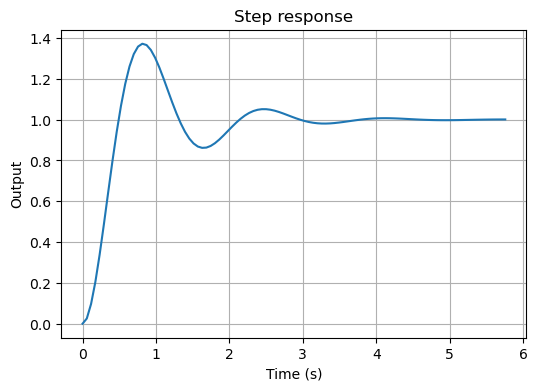

In [6]:
t, y = ct.step_response(G)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, y)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Output')
ax.set_title('Step response')
ax.grid(True)
plt.show()


## Step response info (rise time, overshoot, settling time, ...)

`step_info` gives the standard performance metrics without you having
to eyeball the plot.


In [7]:
info = ct.step_info(G)
for key, val in info.items():
    print(f"{key:20s}: {val}")


RiseTime            : 0.29073044103460177
SettlingTime        : 2.849158322139097
SettlingMin         : 0.8617604976737425
SettlingMax         : 1.3720679440586316
Overshoot           : 37.206794405863164
Undershoot          : 0.0
Peak                : 1.3720679440586316
PeakTime            : 0.8140452348968849
SteadyStateValue    : 1.0


## Bode plot

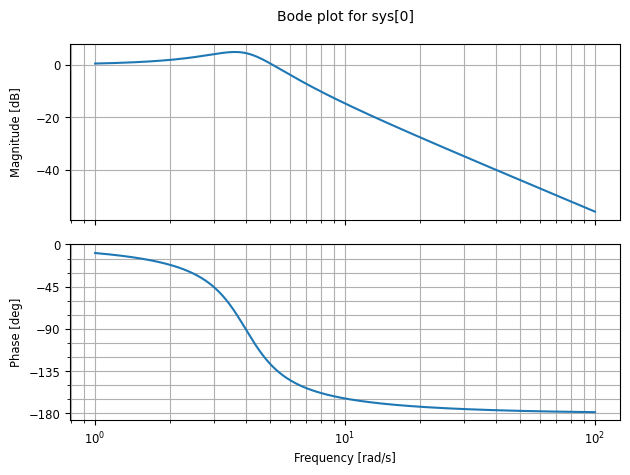

In [8]:
ct.bode_plot(G, dB=True, Hz=False, deg=True)
plt.show()


## Root locus

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


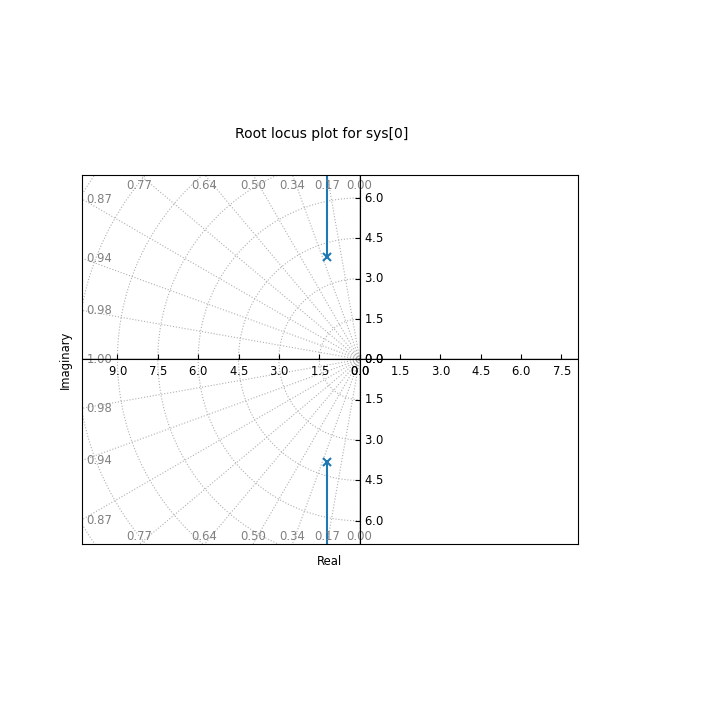

In [9]:
ct.root_locus(G)
plt.show()


## Feedback interconnection

Close the loop with a simple proportional controller and compare the
open-loop vs. closed-loop step response.


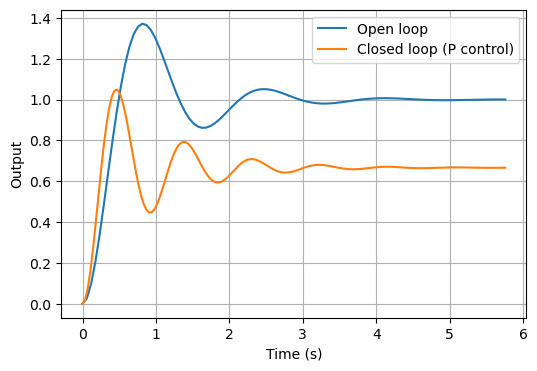

In [10]:
Kp = 2.0
C_ctrl = ct.tf([Kp], [1])          # proportional controller
closed_loop = ct.feedback(C_ctrl * G, 1)   # unity negative feedback

t_ol, y_ol = ct.step_response(G)
t_cl, y_cl = ct.step_response(closed_loop)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_ol, y_ol, label='Open loop')
ax.plot(t_cl, y_cl, label='Closed loop (P control)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Output')
ax.legend()
ax.grid(True)
plt.show()


## Stability margins

Gain margin, phase margin, and the frequencies at which they occur.


In [11]:
gm, pm, wg, wp = ct.margin(G)
print(f"Gain margin:   {gm}")
print(f"Phase margin:  {pm} deg")
print(f"At frequency:  wg={wg}, wp={wp}")


Gain margin:   inf
Phase margin:  50.20818050044275 deg
At frequency:  wg=nan, wp=5.122499389946279


## Note: features requiring `slycot`

Some advanced routines (certain MIMO operations, `hinfsyn`, and a few
robust-control tools) require the optional `slycot` package, which
needs a Fortran compiler and is **not available in Pyodide/JupyterLite**.
Everything above (transfer functions, state-space, step/Bode/root-locus,
feedback, margins) works without it. If a function raises an error
mentioning slycot, that's the reason -- it has no browser-compatible
fallback here.


## Scratch space

Everything below is just working room -- delete/replace freely.
